2D system of ReLU units. Dynamics are:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
W = \begin{pmatrix}
w_{11} & w_{21}\\
w_{12} & w_{22}
\end{pmatrix}
\end{equation}

Each entry in W evolves as:

\begin{equation} 
    \dot{w}_{ij}(t) = - \tilde{x}_i(t) x_j(t) + x_i(t) \tilde{x}_j(t) - x_i (1 - x_i) + x_j (1 - x_j)
\end{equation}

where the $\sim$ denotes a convolutions with an exponentially decaying filter:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-(t - s)/\tau} x(s) \, ds
\end{equation}

For small $\tau$, we can define $v = t - s$. Substituting $s = t - v$ and $dv = -ds$ and changing the integration bounds, we have:

\begin{equation}
    \tilde{x}(t) = \int_t^0 e^{-v/\tau} x(t-v) \, (-dv) = \int_0^t e^{-v/\tau} x(t-v) \, dv
\end{equation}

$x(t-v)$ will only contribute if $v$ is small relative to $tau$, thus we can substitute:

\begin{equation}
    x(t-v) = x(t) - v x'(t) \; + \; ...
\end{equation}

This yields:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-v/\tau} \left(x(t) - v x'(t)\right)  \, dv
\end{equation}

Assuming $\tau << t$, we can use the  identity:

\begin{equation}
    \int_0^{\infty} v^n e^{-v/\tau} = n! \; \tau^{n+1}
\end{equation}

Thus,

\begin{equation}
    \tilde{x}(t) = \tau x(t) - \tau^2 \dot{x}(t)
\end{equation}

The equation governing $W$ then becomes:

\begin{equation}
    \dot{w}_{ij}(t) = - \left(\tau x_i(t) - \tau^2 \dot{x}_i(t)\right) x_j(t) + x_i(t) \left(\tau x_j(t) - \tau^2 \dot{x}_j(t)\right)  - x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[\dot{x}_i(t) x_j(t) - x_i(t) \dot{x}_j(t)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can now search for fixed points of the system by setting all fixed points to zero:

\begin{equation}
    0 = - x_1 (1 - x_1) + x_2 (1 - x_2)
\end{equation}

\begin{equation}
    0 = (w_{11} - 1) x_1 + w_{21} x_2 + u_1
\end{equation}

\begin{equation}
    0 = w_{12} x_1 + (w_{22} - 1) x_2 + u_2
\end{equation}


    

The first equation can be rewritten as

\begin{equation}
    0 = (x_2 - x_1) (1 - (x_1 + x_2))
\end{equation}

yielding that either $x_1 = x_2$ or $x_2 = 1 - x_1$.

Substituting the latter into the second equation yields:

\begin{equation}
    0 = (w_{11} - 1) x_1 + w_{21} (1 - x_1) + u_1
\end{equation}

Regrouping terms

\begin{equation}
    0 = (w_{11} - 1 - w_{21}) x_1 + w_{21} + u_1
\end{equation}

This equation can be satisfied for arbitrary $x_1$ if

\begin{equation}
    w_{11} - 1 - w_{21} = 0
\end{equation}

\begin{equation}
    w_{21} + u_1 = 0
\end{equation}

Similarly, subsituting $x_2 = 1 - x_1$ into the last equation yields:

\begin{equation}
    0 = w_{12} x_1 + (w_{22} - 1) (1 - x_1) + u_2
\end{equation}

\begin{equation}
    0 = (w_{12} - w_{22} + 1) x_1 + w_{22} - 1 + u_2
\end{equation}

This can be true for arbitray $x_1$ if:

\begin{equation}
    0 = w_{12} - w_{22} + 1
\end{equation}

\begin{equation}
    0 = w_{22} - 1 + u_2
\end{equation}

In summary, we have found a line of fixed points corresponding to

\begin{equation}
    x_{2} = 1 - x_1
\end{equation}

\begin{equation}
    w_{12} = -u_2
\end{equation}

\begin{equation}
    w_{21} = -u_1
\end{equation}

for arbitrary $x_1$ under the conditions that:

\begin{equation}
    w_{22} = 1 - u_2
\end{equation}

\begin{equation}
    w_{11} = 1 - u_1
\end{equation}

Note, $w_{11}$ and $w_{22}$ do not evolve under the synaptic update rule since setting $i = j$ leads the update to be zero.




To determine the stability of the fixed point, we must linearize the dynamics about a point of this fixed line.

The total dynamics of the system are given by:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[\dot{x}_i(t) x_j(t) - x_i(t) \dot{x}_j(t)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can substitute the first equation into the second to get:

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[((w_{ii}-1) x_i + w_{ji} x_j + u_i) x_j(t) - x_i(t) ((w_{jj}-1) x_j + w_{ij} x_i + u_j)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can now compute the Jacobian of this system about the fixed line described. We define:

\begin{equation}
    \theta = \begin{pmatrix}
    x_1 \\
    x_2 \\
    w_{21} \\
    w_{12} \\
    \end{pmatrix}
\end{equation}

We would like to compute:

\begin{equation}
    \frac{d}{d \theta} \dot{\theta} |_{\theta^*(x_1^*)} = \frac{d}{d \theta}  F(\theta) |_{\theta^*(x_1^*)}
\end{equation}

where

\begin{equation}
    \theta^*(x_1^*) = \begin{pmatrix}
    x_1^* \\
    1 - x_1^* \\
    -u_1 \\
    -u_2 \\
    \end{pmatrix}
\end{equation}

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def system_derivatives(state, u):
    """
    Compute derivatives for the dynamical system
    state = [w_ij, w_ji, x_i, x_j]
    """
    w_ij, w_ji, x_i, x_j = state
    w_r = 1 - u  # constraint from fixed point analysis
    
    # x derivatives
    dx_i_dt = (w_r - 1) * x_i + w_ji * x_j + u
    dx_j_dt = (w_r - 1) * x_j + w_ij * x_i + u
    
    # w derivatives - CORRECTED VERSION
    # The original equations are:
    # d/dt w_ij = -x_i d/dt x_j + (d/dt x_i) x_j - x_i(1 - x_i) + x_j(1 - x_j)
    # d/dt w_ji = -x_j d/dt x_i + (d/dt x_j) x_i - x_j(1 - x_j) + x_i(1 - x_i)
    
    dw_ij_dt =  -x_i * dx_j_dt + dx_i_dt * x_j + 0.005 * (- x_i * (1 - x_i) + x_j * (1 - x_j))
    dw_ji_dt =  -x_j * dx_i_dt + dx_j_dt * x_i + 0.005 * (- x_j * (1 - x_j) + x_i * (1 - x_i))
    
    return np.array([dw_ij_dt, dw_ji_dt, dx_i_dt, dx_j_dt])

def rk4_step(state, dt, u):
    """Runge-Kutta 4th order integration step with bounds checking"""
    k1 = system_derivatives(state, u)
    k2 = system_derivatives(state + 0.5 * dt * k1, u)
    k3 = system_derivatives(state + 0.5 * dt * k2, u)
    k4 = system_derivatives(state + dt * k3, u)
    
    new_state = state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Prevent x values from going negative or too large (optional bounds)
    new_state[2] = np.clip(new_state[2], 1e-6, 50)  # x_i
    new_state[3] = np.clip(new_state[3], 1e-6, 50)  # x_j
    
    # Check for NaN or infinity
    if np.any(~np.isfinite(new_state)):
        print(f"Warning: Non-finite values detected at state {state}")
        print(f"Derivatives: {k1}")
        return state  # Return previous state if numerical issues
    
    return new_state

def simulate_system(initial_conditions, u, dt=0.01, max_time=10):
    """
    Simulate the dynamical system with stability checks
    """
    num_steps = int(max_time / dt)
    time_points = np.linspace(0, max_time, num_steps + 1)
    
    trajectories = []
    
    for j, initial in enumerate(initial_conditions):
        trajectory = np.zeros((num_steps + 1, 4))
        trajectory[0] = initial
        
        state = initial.copy()
        for i in range(num_steps):
            new_state = rk4_step(state, dt, u)
            
            # Check for numerical instability
            if np.any(np.abs(new_state) > 100):
                print(f"Trajectory {j+1}: Large values detected at step {i}, time {i*dt:.3f}")
                print(f"State: {new_state}")
                # Truncate trajectory at this point
                trajectory = trajectory[:i+1]
                time_points_truncated = time_points[:i+1]
                break
            
            trajectory[i + 1] = new_state
            state = new_state
            
        trajectories.append(trajectory)
    
    return time_points, trajectories

def generate_initial_conditions(a, u, num_trajectories=5, perturbation=0.1):
    """Generate initial conditions with smaller perturbations"""
    fixed_point = np.array([-u, -u, a, 1 - a])  # [w_ij, w_ji, x_i, x_j]
    
    initial_conditions = []
    np.random.seed(42)  # for reproducibility
    
    for i in range(num_trajectories):
        # Smaller perturbations to avoid instability
        perturbations = (np.random.rand(4) - 0.5) * perturbation
        
        # Ensure x values stay in reasonable bounds
        initial = fixed_point + perturbations
        initial[2] = np.clip(initial[2], 0.01, 0.95)  # x_i
        initial[3] = np.clip(initial[3], 0.01, 0.95)  # x_j
        
        initial_conditions.append(initial)
    
    return initial_conditions

def plot_results(time_points, trajectories, u, a):
    """Plot the simulation results with error handling"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Fixed point values
    w_eq = 1 - u
    x_i_eq = a
    x_j_eq = 1 - a
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(trajectories)))
    
    # Plot 1: X variables
    ax1 = axes[0, 0]
    for i, traj in enumerate(trajectories):
        # Handle different trajectory lengths
        t_len = len(traj)
        t_vals = time_points[:t_len] if t_len <= len(time_points) else time_points
        
        # Only plot finite values
        finite_mask = np.isfinite(traj[:, 2]) & np.isfinite(traj[:, 3])
        
        if np.any(finite_mask):
            ax1.plot(t_vals[finite_mask], traj[finite_mask, 2], color=colors[i], 
                    label=f'x_i (traj {i+1})', linewidth=2)
            ax1.plot(t_vals[finite_mask], traj[finite_mask, 3], color=colors[i], 
                    linestyle='--', label=f'x_j (traj {i+1})', alpha=0.7)
    
    ax1.axhline(y=x_i_eq, color='red', linestyle=':', alpha=0.8, label=f'x_i equilibrium = {x_i_eq}')
    ax1.axhline(y=x_j_eq, color='blue', linestyle=':', alpha=0.8, label=f'x_j equilibrium = {x_j_eq:.2f}')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Value')
    ax1.set_title('X Variables')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)
    
    # Plot 2: W variables
    ax2 = axes[0, 1]
    for i, traj in enumerate(trajectories):
        t_len = len(traj)
        t_vals = time_points[:t_len] if t_len <= len(time_points) else time_points
        
        finite_mask = np.isfinite(traj[:, 0]) & np.isfinite(traj[:, 1])
        
        if np.any(finite_mask):
            ax2.plot(t_vals[finite_mask], traj[finite_mask, 0], color=colors[i], 
                    label=f'w_ij (traj {i+1})', linewidth=2, alpha=0.3)
            ax2.plot(t_vals[finite_mask], traj[finite_mask, 1], color=colors[i], 
                    linestyle='--', label=f'w_ji (traj {i+1})', alpha=0.3)
    
    ax2.axhline(y=w_eq-1, color='red', linestyle=':', alpha=0.8, label=f'w equilibrium = {w_eq-1:.2f}')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Value')
    ax2.set_title('W Variables')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)
    
    # Plot 3: Sum and Difference
    ax3 = axes[1, 0]
    for i, traj in enumerate(trajectories):
        t_len = len(traj)
        t_vals = time_points[:t_len] if t_len <= len(time_points) else time_points
        
        finite_mask = np.isfinite(traj[:, 2]) & np.isfinite(traj[:, 3])
        
        if np.any(finite_mask):
            x_sum = traj[finite_mask, 2] + traj[finite_mask, 3]
            x_diff = traj[finite_mask, 2] - traj[finite_mask, 3]
            ax3.plot(t_vals[finite_mask], x_sum, color=colors[i], 
                    label=f'x_i + x_j (traj {i+1})', linewidth=2)
            ax3.plot(t_vals[finite_mask], x_diff, color=colors[i], 
                    linestyle='--', label=f'x_i - x_j (traj {i+1})', alpha=0.7)
    
    ax3.axhline(y=1, color='red', linestyle=':', alpha=0.8, label='Sum equilibrium = 1')
    ax3.axhline(y=2*a-1, color='blue', linestyle=':', alpha=0.8, label=f'Diff equilibrium = {2*a-1:.2f}')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Value')
    ax3.set_title('Sum and Difference (Stability Analysis)')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=8)
    
    # Plot 4: Phase portrait (x_i vs x_j)
    ax4 = axes[1, 1]
    for i, traj in enumerate(trajectories):
        finite_mask = np.isfinite(traj[:, 2]) & np.isfinite(traj[:, 3])
        
        if np.any(finite_mask):
            valid_traj = traj[finite_mask]
            if len(valid_traj) > 0:
                ax4.plot(valid_traj[:, 2], valid_traj[:, 3], color=colors[i], 
                        label=f'Trajectory {i+1}', linewidth=2)
                ax4.plot(valid_traj[0, 2], valid_traj[0, 3], 'o', color=colors[i], 
                        markersize=8)
                ax4.plot(valid_traj[-1, 2], valid_traj[-1, 3], 's', color=colors[i], 
                        markersize=8)
    
    ax4.plot(x_i_eq, x_j_eq, 'r*', markersize=15, label='Fixed Point')
    ax4.set_xlabel('x_i')
    ax4.set_ylabel('x_j')
    ax4.set_title('Phase Portrait (x_i vs x_j)')
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

def main():
    # Parameters - using smaller dt for stability
    u = 0.3          
    a = 0.4          
    dt = 0.005       # Smaller time step
    max_time = 100     # Shorter time to avoid instability
    num_trajectories = 5
    perturbation = 0.25  # Smaller perturbations
    
    print(f"Simulating system with parameters:")
    print(f"u = {u}")
    print(f"a = {a} (equilibrium x_i)")
    print(f"w_r = 1 - u = {1-u}")
    print(f"dt = {dt} (time step)")
    print(f"Fixed point: w_ij = w_ji = {1-u-1:.2f}, x_i = {a}, x_j = {1-a}")
    print()
    
    # Generate initial conditions
    initial_conditions = []
    for a in np.linspace(0.1, 0.9, 10):
        initial_conditions += generate_initial_conditions(a, u, num_trajectories, perturbation)
    
    print("Initial conditions:")
    for i, ic in enumerate(initial_conditions):
        print(f"Trajectory {i+1}: w_ij={ic[0]:.3f}, w_ji={ic[1]:.3f}, x_i={ic[2]:.3f}, x_j={ic[3]:.3f}")
    print()
    
    # Run simulation
    print("Running simulation...")
    time_points, trajectories = simulate_system(initial_conditions, u, dt, max_time)
    
    # Plot results
    plot_results(time_points, trajectories, u, a)
    
    # Analyze final states (only for trajectories that didn't blow up)
    print("Final states (last valid values):")
    for i, traj in enumerate(trajectories):
        if len(traj) > 0:
            final_state = traj[-1]
            if np.all(np.isfinite(final_state)):
                print(f"Trajectory {i+1}: w_ij={final_state[0]:.3f}, w_ji={final_state[1]:.3f}, "
                      f"x_i={final_state[2]:.3f}, x_j={final_state[3]:.3f}")
                print(f"  Sum: {final_state[2] + final_state[3]:.3f}, Diff: {final_state[2] - final_state[3]:.3f}")
            else:
                print(f"Trajectory {i+1}: Contains non-finite values")

Simulating system with parameters:
u = 0.3
a = 0.4 (equilibrium x_i)
w_r = 1 - u = 0.7
dt = 0.005 (time step)
Fixed point: w_ij = w_ji = -0.30, x_i = 0.4, x_j = 0.6

Initial conditions:
Trajectory 1: w_ij=-0.331, w_ji=-0.187, x_i=0.158, x_j=0.925
Trajectory 2: w_ij=-0.386, w_ji=-0.386, x_i=0.010, x_j=0.950
Trajectory 3: w_ij=-0.275, w_ji=-0.248, x_i=0.010, x_j=0.950
Trajectory 4: w_ij=-0.217, w_ji=-0.372, x_i=0.020, x_j=0.821
Trajectory 5: w_ij=-0.349, w_ji=-0.294, x_i=0.083, x_j=0.848
Trajectory 6: w_ij=-0.331, w_ji=-0.187, x_i=0.247, x_j=0.836
Trajectory 7: w_ij=-0.386, w_ji=-0.386, x_i=0.078, x_j=0.903
Trajectory 8: w_ij=-0.275, w_ji=-0.248, x_i=0.069, x_j=0.929
Trajectory 9: w_ij=-0.217, w_ji=-0.372, x_i=0.109, x_j=0.732
Trajectory 10: w_ij=-0.349, w_ji=-0.294, x_i=0.172, x_j=0.759
Trajectory 11: w_ij=-0.331, w_ji=-0.187, x_i=0.336, x_j=0.747
Trajectory 12: w_ij=-0.386, w_ji=-0.386, x_i=0.167, x_j=0.814
Trajectory 13: w_ij=-0.275, w_ji=-0.248, x_i=0.158, x_j=0.840
Trajectory 14: w_

/tmp/ipykernel_2239876/2950491743.py:202: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


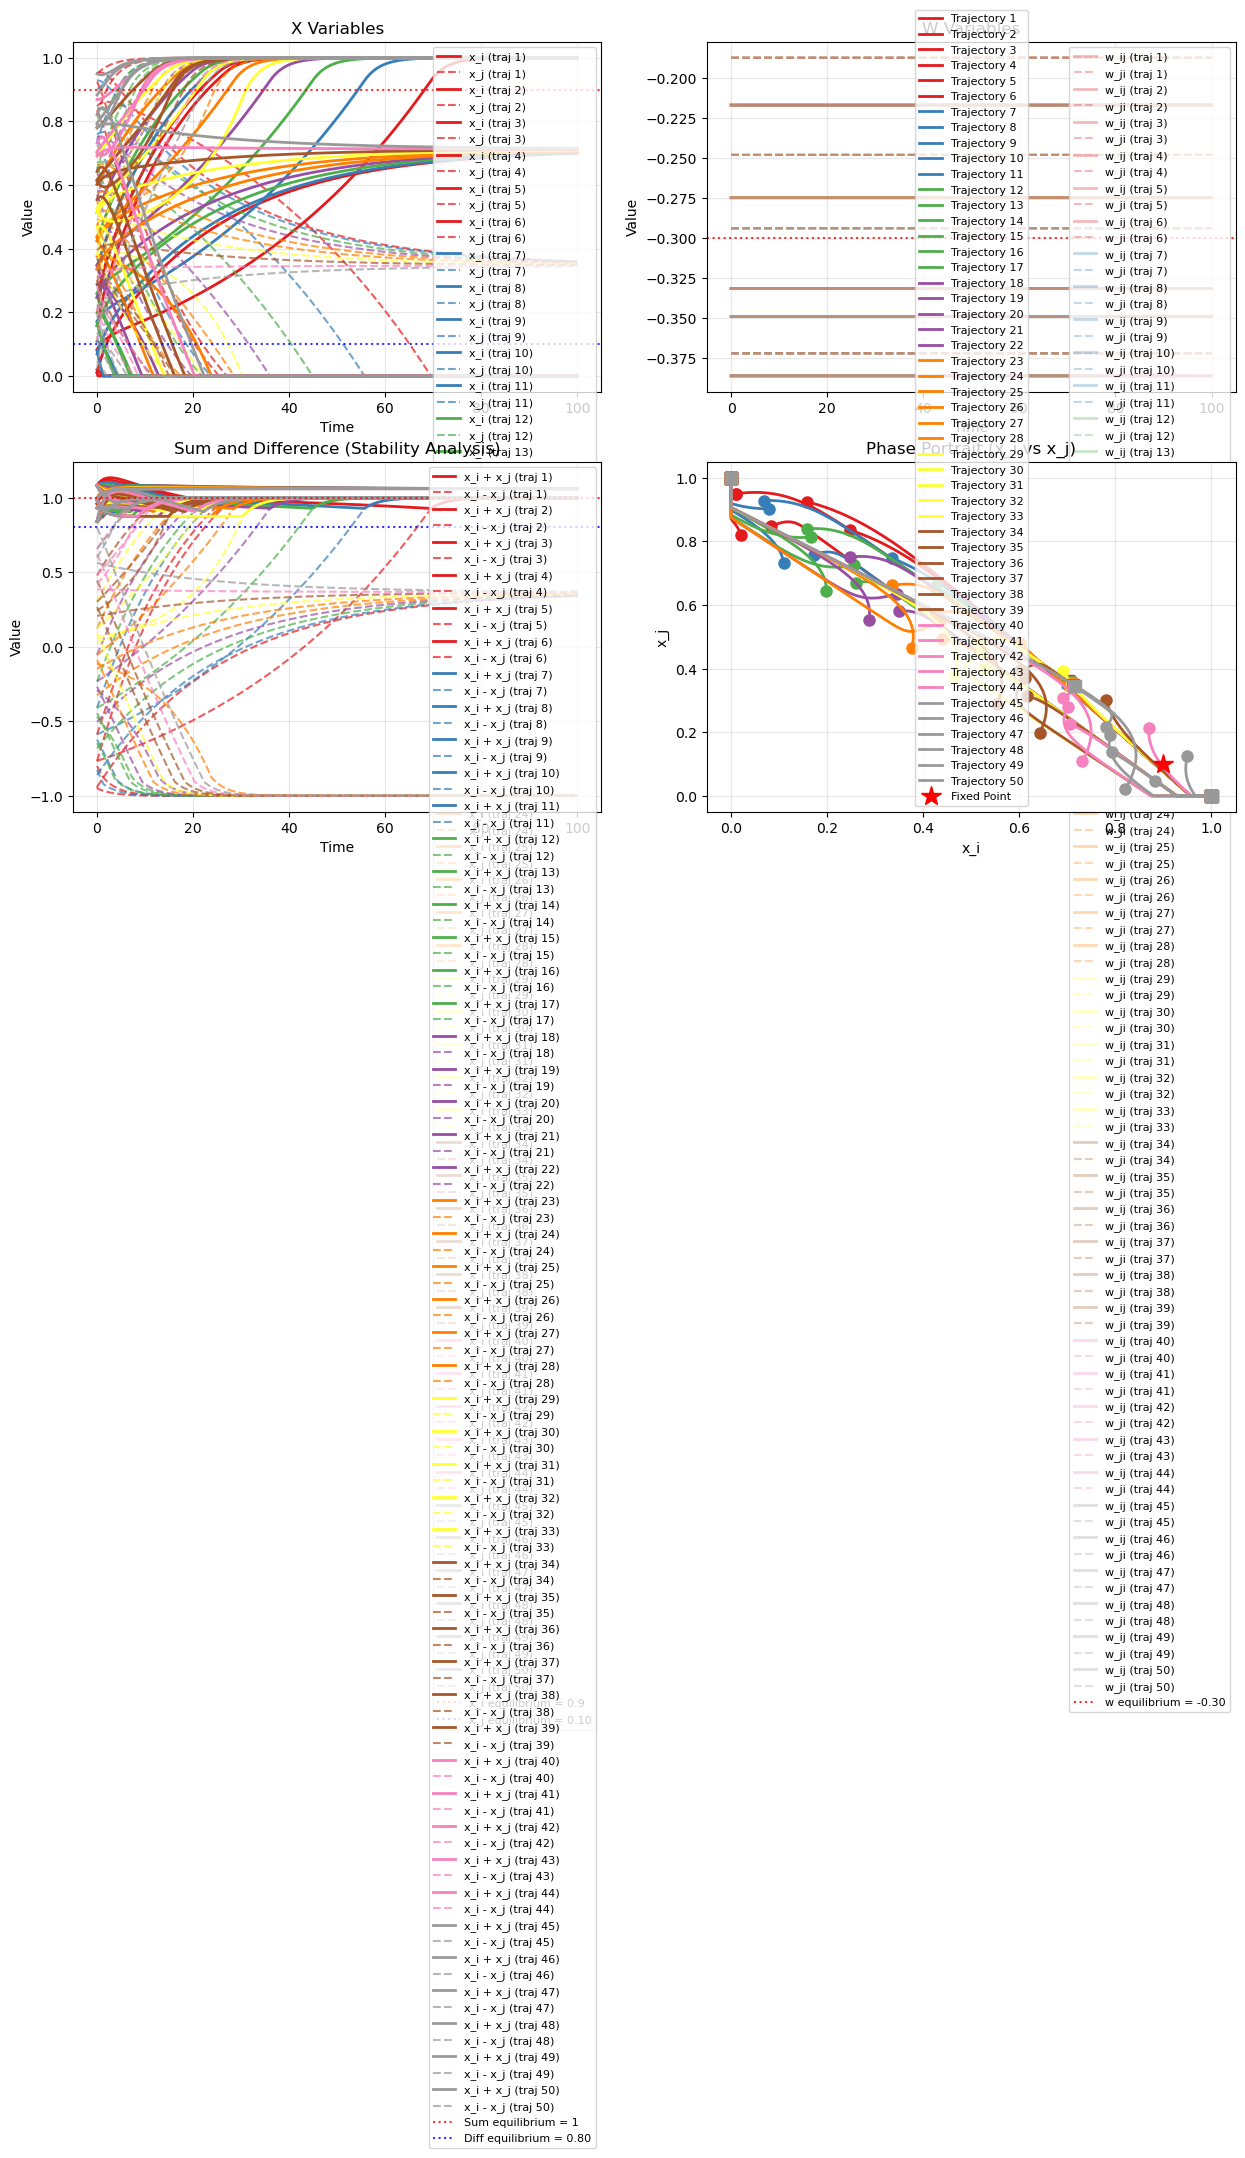

Final states (last valid values):
Trajectory 1: w_ij=-0.331, w_ji=-0.187, x_i=1.000, x_j=0.000
  Sum: 1.000, Diff: 1.000
Trajectory 2: w_ij=-0.386, w_ji=-0.386, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 3: w_ij=-0.275, w_ji=-0.248, x_i=0.700, x_j=0.360
  Sum: 1.061, Diff: 0.340
Trajectory 4: w_ij=-0.217, w_ji=-0.372, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 5: w_ij=-0.349, w_ji=-0.294, x_i=1.000, x_j=0.000
  Sum: 1.000, Diff: 1.000
Trajectory 6: w_ij=-0.331, w_ji=-0.187, x_i=1.000, x_j=0.000
  Sum: 1.000, Diff: 1.000
Trajectory 7: w_ij=-0.386, w_ji=-0.386, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 8: w_ij=-0.275, w_ji=-0.248, x_i=0.701, x_j=0.359
  Sum: 1.061, Diff: 0.342
Trajectory 9: w_ij=-0.217, w_ji=-0.372, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 10: w_ij=-0.349, w_ji=-0.294, x_i=1.000, x_j=0.000
  Sum: 1.000, Diff: 1.000
Trajectory 11: w_ij=-0.331, w_ji=-0.187, x_i=1.000, x_j=0.000
  Sum: 1.000, Diff: 1.000
Tra

In [39]:
main()

Simulating system with parameters:
u = 0.3
a = 0.4 (equilibrium x_i)
w_r = 1 - u = 0.7
dt = 0.005 (time step)
Fixed point: w_ij = w_ji = -0.30, x_i = 0.4, x_j = 0.6

Initial conditions:
Trajectory 1: w_ij=-0.331, w_ji=-0.187, x_i=0.158, x_j=0.925
Trajectory 2: w_ij=-0.386, w_ji=-0.386, x_i=0.010, x_j=0.950
Trajectory 3: w_ij=-0.275, w_ji=-0.248, x_i=0.010, x_j=0.950
Trajectory 4: w_ij=-0.217, w_ji=-0.372, x_i=0.020, x_j=0.821
Trajectory 5: w_ij=-0.349, w_ji=-0.294, x_i=0.083, x_j=0.848
Trajectory 6: w_ij=-0.331, w_ji=-0.187, x_i=0.247, x_j=0.836
Trajectory 7: w_ij=-0.386, w_ji=-0.386, x_i=0.078, x_j=0.903
Trajectory 8: w_ij=-0.275, w_ji=-0.248, x_i=0.069, x_j=0.929
Trajectory 9: w_ij=-0.217, w_ji=-0.372, x_i=0.109, x_j=0.732
Trajectory 10: w_ij=-0.349, w_ji=-0.294, x_i=0.172, x_j=0.759
Trajectory 11: w_ij=-0.331, w_ji=-0.187, x_i=0.336, x_j=0.747
Trajectory 12: w_ij=-0.386, w_ji=-0.386, x_i=0.167, x_j=0.814
Trajectory 13: w_ij=-0.275, w_ji=-0.248, x_i=0.158, x_j=0.840
Trajectory 14: w_

/tmp/ipykernel_2239876/1101574644.py:202: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


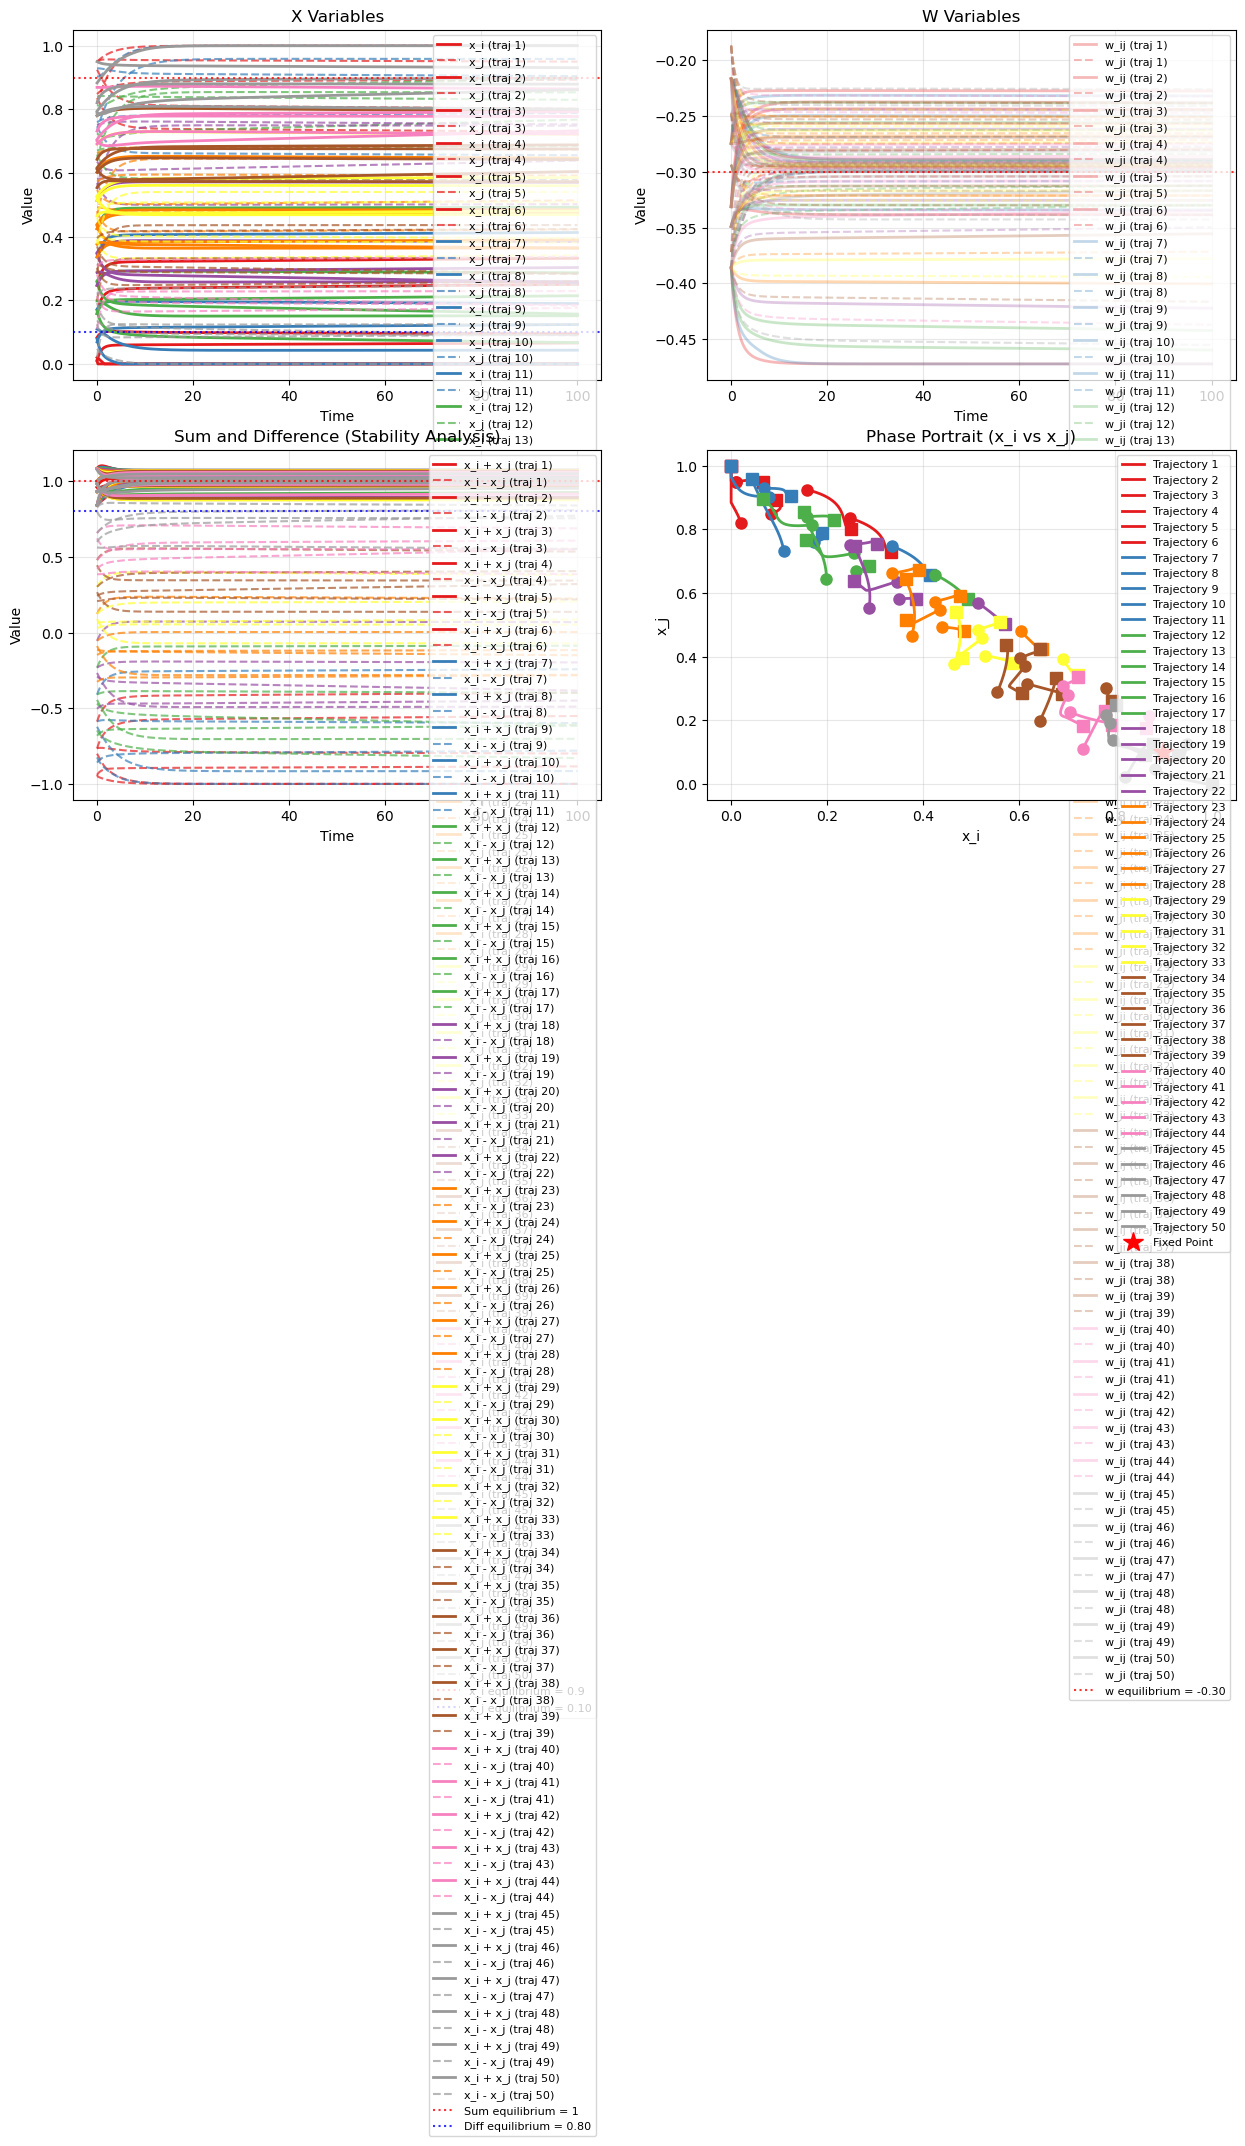

Final states (last valid values):
Trajectory 1: w_ij=-0.238, w_ji=-0.280, x_i=0.250, x_j=0.802
  Sum: 1.052, Diff: -0.551
Trajectory 2: w_ij=-0.472, w_ji=-0.300, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 3: w_ij=-0.228, w_ji=-0.295, x_i=0.066, x_j=0.950
  Sum: 1.016, Diff: -0.884
Trajectory 4: w_ij=-0.289, w_ji=-0.300, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 5: w_ij=-0.339, w_ji=-0.304, x_i=0.094, x_j=0.893
  Sum: 0.988, Diff: -0.799
Trajectory 6: w_ij=-0.244, w_ji=-0.274, x_i=0.332, x_j=0.730
  Sum: 1.062, Diff: -0.398
Trajectory 7: w_ij=-0.472, w_ji=-0.300, x_i=0.000, x_j=1.000
  Sum: 1.000, Diff: -1.000
Trajectory 8: w_ij=-0.232, w_ji=-0.291, x_i=0.124, x_j=0.904
  Sum: 1.028, Diff: -0.781
Trajectory 9: w_ij=-0.289, w_ji=-0.300, x_i=0.043, x_j=0.958
  Sum: 1.002, Diff: -0.915
Trajectory 10: w_ij=-0.334, w_ji=-0.308, x_i=0.190, x_j=0.788
  Sum: 0.978, Diff: -0.599
Trajectory 11: w_ij=-0.250, w_ji=-0.268, x_i=0.413, x_j=0.656
  Sum: 1.069, Diff: -0.

In [41]:
main()